# E-commerce Sales & Customer Analytics

This notebook analyzes the UCI Online Retail transactional dataset to answer practical e-commerce business questions around sales performance, product performance, customer behavior, cancellations, and revenue concentration.

### Business Questions

- How does sales performance change over time?
- Which countries contribute the most revenue?
- Which products drive gross and net revenue?
- Which customers generate the most value?
- How important are repeat customers?
- How concentrated is revenue across customers?

The analysis follows a business-oriented workflow:

**Raw Data → Data Understanding → Cleaning → Feature Engineering → KPI Analysis → EDA → Business Insights**

## Phase 1 — Data Understanding

### 1.1 Load & Structural Inspection


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)


In [2]:
file_path = "../data/Online Retail.xlsx"

df = pd.read_excel(file_path)

In [3]:
df.shape

(541909, 8)

In [4]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [5]:
df.columns.tolist()

['InvoiceNo',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country']

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


### 1.2 Data Quality Profiling


In [7]:
# Missing values
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
# Missing value percentages
(df.isna().mean() * 100).round(2)

InvoiceNo       0.00
StockCode       0.00
Description     0.27
Quantity        0.00
InvoiceDate     0.00
UnitPrice       0.00
CustomerID     24.93
Country         0.00
dtype: float64

In [9]:
# Exact duplicate rows
df.duplicated().sum()
#(df.duplicated().mean()*100).round(2)

np.int64(5268)

In [10]:
df[["Quantity", "UnitPrice"]].describe()

,Quantity,UnitPrice
count,541909.000000,541909.000000
mean,9.552250,4.611114
std,218.081158,96.759853
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


### Initial Data Quality Findings

- CustomerID is missing in 24.93% of transaction rows, which may limit customer-level analysis.
- Description has a relatively small number of missing values (0.27%).
- The dataset contains 5,268 exact duplicate rows that require validation.
- Quantity contains both positive and negative values, requiring investigation of cancellations and returns.
- UnitPrice contains zero/negative and extreme values that require further inspection before revenue calculations.

### 1.3 Investigating Transaction Anomalies

**Business question:** What do negative quantities, cancellation invoices, and unusual prices represent?


In [11]:
quantity_summary = pd.Series({
    "Positive": (df["Quantity"] > 0).sum(),
    "Zero": (df["Quantity"] == 0).sum(),
    "Negative": (df["Quantity"] < 0).sum()
})

quantity_summary

Positive    531285
Zero             0
Negative     10624
dtype: int64

In [12]:
cancellation_mask = df["InvoiceNo"].astype(str).str.startswith("C")

cancellation_mask.sum()

np.int64(9288)

In [13]:
df.loc[cancellation_mask, "InvoiceNo"].nunique()

3836

In [14]:
pd.crosstab(
    df["Quantity"] < 0,
    cancellation_mask,
    rownames=["Negative Quantity"],
    colnames=["Cancellation Invoice"]
)

Cancellation Invoice,False,True
Negative Quantity,,
False,531285,0
True,1336,9288


All invoice lines explicitly marked as cancellations have negative quantities, but not all negative-quantity records are cancellation invoices.

In [15]:
price_summary = pd.Series({
    "Positive": (df["UnitPrice"] > 0).sum(),
    "Zero": (df["UnitPrice"] == 0).sum(),
    "Negative": (df["UnitPrice"] < 0).sum()
})

price_summary

Positive    539392
Zero          2515
Negative         2
dtype: int64

In [16]:
df[df["UnitPrice"] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


Records with negative UnitPrice correspond to bad-debt accounting adjustments rather than product sales and are therefore excluded from sales KPIs.

In [17]:
df[df["Quantity"].abs() == 80995]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,16446.0,United Kingdom


### 1.4 Investigating Negative Non-Cancellation Records

**Business question:** If some negative quantities are not cancellation invoices, what type of records are they?


In [18]:
non_cancel_negative = df[
    (df["Quantity"] < 0) &
    (~cancellation_mask)
]

non_cancel_negative.head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom
4347,536764,84952C,NaN,-38,2010-12-02 14:42:00,0.0,NaN,United Kingdom
7188,536996,22712,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7189,536997,22028,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7190,536998,85067,NaN,-6,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7192,537000,21414,NaN,-22,2010-12-03 15:32:00,0.0,NaN,United Kingdom
7193,537001,21653,NaN,-6,2010-12-03 15:33:00,0.0,NaN,United Kingdom
7195,537003,85126,NaN,-2,2010-12-03 15:33:00,0.0,NaN,United Kingdom
7196,537004,21814,NaN,-30,2010-12-03 15:34:00,0.0,NaN,United Kingdom
7197,537005,21692,NaN,-70,2010-12-03 15:35:00,0.0,NaN,United Kingdom


In [19]:
non_cancel_negative["Description"].value_counts(dropna=False).head(20)

Description
NaN                           862
check                         120
damages                        45
damaged                        42
?                              41
sold as set on dotcom          20
Damaged                        14
thrown away                     9
Unsaleable, destroyed.          9
??                              7
damages?                        5
wet damaged                     5
ebay                            5
smashed                         4
missing                         3
CHECK                           3
wet pallet                      3
Dotcom sales                    2
reverse 21/5/10 adjustment      2
counted                         2
Name: count, dtype: int64

In [20]:
non_cancel_negative["StockCode"].value_counts().head(20)

StockCode
85175     5
21830     5
85172     4
22719     4
82494L    4
72802C    4
21161     3
22162     3
22034     3
20966     3
22423     3
20892     3
46000S    3
22501     3
22837     3
84631     3
35954     3
84406B    3
22114     3
21621     3
Name: count, dtype: int64

In [21]:
zero_price = df[df["UnitPrice"] == 0]

zero_price.head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom


In [22]:
zero_price["Description"].value_counts(dropna=False).head(20)

Description
NaN                                1454
check                               159
?                                    47
damages                              45
damaged                              43
found                                25
sold as set on dotcom                20
adjustment                           16
Damaged                              14
FRENCH BLUE METAL DOOR SIGN 1         9
thrown away                           9
Unsaleable, destroyed.                9
amazon                                8
FRENCH BLUE METAL DOOR SIGN 8         8
Found                                 8
FRENCH BLUE METAL DOOR SIGN 4         7
FRENCH BLUE METAL DOOR SIGN No        7
OWL DOORSTOP                          7
FRENCH BLUE METAL DOOR SIGN 3         7
RECIPE BOX PANTRY YELLOW DESIGN       7
Name: count, dtype: int64

In [23]:
pd.crosstab(
    zero_price["Quantity"] < 0,
    zero_price["CustomerID"].isna(),
    rownames=["Negative Quantity"],
    colnames=["Missing CustomerID"]
)

Missing CustomerID,False,True
Negative Quantity,,
False,40,1139
True,0,1336


In [24]:
missing_description = df[df["Description"].isna()]

missing_description[
    ["InvoiceNo", "StockCode", "Quantity", "UnitPrice", "CustomerID"]
].head(20)

,InvoiceNo,StockCode,Quantity,UnitPrice,CustomerID
622,536414,22139,56,0.0,NaN
1970,536545,21134,1,0.0,NaN
1971,536546,22145,1,0.0,NaN
1972,536547,37509,1,0.0,NaN
1987,536549,85226A,1,0.0,NaN
1988,536550,85044,1,0.0,NaN
2024,536552,20950,1,0.0,NaN
2025,536553,37461,3,0.0,NaN
2026,536554,84670,23,0.0,NaN
2406,536589,21777,-10,0.0,NaN


In [25]:
pd.Series({
    "Total": len(missing_description),
    "Negative Quantity": (missing_description["Quantity"] < 0).sum(),
    "Zero Price": (missing_description["UnitPrice"] == 0).sum(),
    "Missing CustomerID": missing_description["CustomerID"].isna().sum()
})

Total                 1454
Negative Quantity      862
Zero Price            1454
Missing CustomerID    1454
dtype: int64

Negative quantities without cancellation invoice numbers represent operational or inventory adjustments rather than customer sales transactions.

Further investigation showed that negative quantities were not exclusively
customer cancellations. All 1,336 negative-quantity records without a
"C"-prefixed invoice had zero unit prices and missing customer IDs, with
descriptions such as "damages", "thrown away", and "check". These records
appear to represent internal inventory adjustments and should not be treated
as customer sales or returns.

In [26]:
df[
    (df["UnitPrice"] == 0) &
    (df["CustomerID"].notna())
][
    [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "CustomerID"
    ]
]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,CustomerID
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,12647.0
33576,539263,22580,ADVENT CALENDAR GINGHAM SACK,4,2010-12-16 14:36:00,16560.0
40089,539722,22423,REGENCY CAKESTAND 3 TIER,10,2010-12-21 13:45:00,14911.0
47068,540372,22090,PAPER BUNTING RETROSPOT,24,2011-01-06 16:41:00,13081.0
47070,540372,22553,PLASTERS IN TIN SKULLS,24,2011-01-06 16:41:00,13081.0
56674,541109,22168,ORGANISER WOOD ANTIQUE WHITE,1,2011-01-13 15:10:00,15107.0
86789,543599,84535B,FAIRY CAKES NOTEBOOK A6 SIZE,16,2011-02-10 13:08:00,17560.0
130188,547417,22062,CERAMIC BOWL WITH LOVE HEART DESIGN,36,2011-03-23 10:25:00,13239.0
139453,548318,22055,MINI CAKE STAND HANGING STRAWBERY,5,2011-03-30 12:45:00,13113.0
145208,548871,22162,HEART GARLAND RUSTIC PADDED,2,2011-04-04 14:42:00,14410.0


Zero-priced transactions are retained in the cleaned source data but excluded from paid-sales KPIs and product sales rankings because their commercial meaning cannot be reliably determined.

In [27]:
duplicate_rows = df[
    df.duplicated(keep=False)
].sort_values(
    ["InvoiceNo", "StockCode", "InvoiceDate"]
)

duplicate_rows.head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
565,536412,21448,12 DAISY PEGS IN WOOD BOX,2,2010-12-01 11:49:00,1.65,17920.0,United Kingdom
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom


In [28]:
len(duplicate_rows)

10147

The raw dataset contained 5,268 exact duplicate rows. Since all available
transaction attributes were identical, only one copy of each duplicated
record was retained to avoid double-counting sales, quantities, and revenue.

## Phase 2 — Data Cleaning


In [29]:
df_clean = df.copy()

### 2.1 Exact Duplicates


In [30]:
rows_before = len(df_clean)

df_clean = df_clean.drop_duplicates().copy()

rows_after = len(df_clean)

print(f"Rows before: {rows_before:,}")
print(f"Rows after:  {rows_after:,}")
print(f"Removed:     {rows_before - rows_after:,}")

Rows before: 541,909
Rows after:  536,641
Removed:     5,268


### 2.2 Transaction Flags


In [31]:
df_clean["IsCancellation"] = (
    df_clean["InvoiceNo"]
    .astype(str)
    .str.startswith("C")
)

df_clean["IsZeroPrice"] = df_clean["UnitPrice"] == 0

df_clean["IsNegativePrice"] = df_clean["UnitPrice"] < 0

df_clean["HasCustomerID"] = df_clean["CustomerID"].notna()

In [32]:
df_clean["IsOperationalAdjustment"] = (
    (df_clean["Quantity"] < 0) &
    (~df_clean["IsCancellation"]) &
    (df_clean["UnitPrice"] == 0) &
    (df_clean["CustomerID"].isna())
)

In [33]:
df_clean["CustomerID"] = df_clean["CustomerID"].astype("Int64")

In [34]:
df_clean[
    [
        "IsCancellation",
        "IsZeroPrice",
        "IsNegativePrice",
        "IsOperationalAdjustment"
    ]
].sum()

IsCancellation             9251
IsZeroPrice                2510
IsNegativePrice               2
IsOperationalAdjustment    1336
dtype: int64

### 2.3 Analytical Dataset Definitions


**Business question:** Which transaction records should be used for paid-sales, cancellation, and customer-level analyses?


#### Paid sales dataset (`sales_df`)


In [35]:
sales_df = df_clean[
    (~df_clean["IsCancellation"]) &
    (df_clean["Quantity"] > 0) &
    (df_clean["UnitPrice"] > 0)
].copy()

#### Cancellation dataset (`cancellations_df`)


In [36]:
cancellations_df = df_clean[
    (df_clean["IsCancellation"]) &
    (df_clean["Quantity"] < 0) &
    (df_clean["UnitPrice"] > 0)
].copy()

#### Customer dataset (`customer_df`)


In [37]:
sales_df["Revenue"] = (
    sales_df["Quantity"] * sales_df["UnitPrice"]
)

In [38]:
cancellations_df["Revenue"] = (
    cancellations_df["Quantity"] * cancellations_df["UnitPrice"]
)

In [39]:
customer_df = sales_df[
    sales_df["CustomerID"].notna()
].copy()

In [40]:
print(f"Clean rows:          {len(df_clean):,}")
print(f"Paid sales rows:     {len(sales_df):,}")
print(f"Cancellation rows:   {len(cancellations_df):,}")
print(f"Customer sales rows: {len(customer_df):,}")


Clean rows:          536,641
Paid sales rows:     524,878
Cancellation rows:   9,251
Customer sales rows: 392,692


In [41]:
revenue_summary = pd.Series({
    "Gross Revenue": sales_df["Revenue"].sum(),
    "Cancellation Value": -cancellations_df["Revenue"].sum(),
    "Net Revenue": (
        sales_df["Revenue"].sum()
        + cancellations_df["Revenue"].sum()
    )
})

revenue_summary.apply(lambda x: f"£{x:,.2f}")

Gross Revenue         £10,642,110.80
Cancellation Value       £893,979.73
Net Revenue            £9,748,131.07
dtype: str

In [42]:
pd.Series({
    "Sales Invoices": sales_df["InvoiceNo"].nunique(),
    "Cancellation Invoices": cancellations_df["InvoiceNo"].nunique(),
    "Customers in Sales Data": customer_df["CustomerID"].nunique()
})

Sales Invoices             19960
Cancellation Invoices       3836
Customers in Sales Data     4338
dtype: int64

In [43]:
pd.Series({
    "Paid Sales Rows": len(sales_df),
    "Paid Sales Rows with CustomerID": sales_df["CustomerID"].notna().sum(),
    "Paid Sales Rows without CustomerID": sales_df["CustomerID"].isna().sum(),
    "CustomerID Coverage (%)": sales_df["CustomerID"].notna().mean() * 100
}).round(2)

Paid Sales Rows                       524878.00
Paid Sales Rows with CustomerID       392692.00
Paid Sales Rows without CustomerID    132186.00
CustomerID Coverage (%)                   74.82
dtype: float64

### Data Cleaning Summary

The raw dataset contained 541,909 transaction lines. After removing 5,268 exact duplicate records, 536,641 rows remained.

Transactions were classified based on their business meaning rather than applying blanket filtering rules. Positive paid transactions were separated from cancellation invoices, zero-priced operational records, and accounting adjustments.

The resulting paid-sales dataset contains 524,878 transaction lines across 19,960 invoices. Customer-level analysis is performed on the subset with identifiable customers, containing 392,692 transaction lines and 4,338 unique customers. Customer IDs are available for 74.82% of paid-sales transaction lines.

Cancellation records were retained separately so that their financial impact can be analyzed rather than being silently discarded.

> **Revenue scope note:** `sales_df` represents positive, non-cancellation transaction lines with a positive unit price. This means invoiced non-merchandise charges can remain part of transaction-level revenue. Product rankings use a stricter merchandise-only subset so that postage, fees, manual entries, and accounting adjustments are not treated as products.

## Phase 3 — Feature Engineering & KPI Definitions


**Business question:** How should transaction-level records be transformed into meaningful business metrics?


### 3.1 Time Features


In [44]:
sales_df["YearMonth"] = (
    sales_df["InvoiceDate"]
    .dt.to_period("M")
)

In [45]:
cancellations_df["YearMonth"] = (
    cancellations_df["InvoiceDate"]
    .dt.to_period("M")
)

In [46]:
customer_df["YearMonth"] = (
    customer_df["InvoiceDate"]
    .dt.to_period("M")
)

In [47]:
sales_df["Weekday"] = sales_df["InvoiceDate"].dt.day_name()
sales_df["Hour"] = sales_df["InvoiceDate"].dt.hour

### 3.2 Order-Level Features


In [48]:
orders_df = (
    sales_df
    .groupby("InvoiceNo", as_index=False)
    .agg(
        InvoiceDate=("InvoiceDate", "min"),
        OrderValue=("Revenue", "sum"),
        Items=("Quantity", "sum"),
        ProductLines=("StockCode", "count"),
        UniqueProducts=("StockCode", "nunique")
    )
)


In [49]:
len(orders_df)

19960

In [50]:
assert len(orders_df) == sales_df["InvoiceNo"].nunique()

In [51]:
orders_df.head()

,InvoiceNo,InvoiceDate,OrderValue,Items,ProductLines,UniqueProducts
0,536365,2010-12-01 08:26:00,139.12,40,7,7
1,536366,2010-12-01 08:28:00,22.20,12,2,2
2,536367,2010-12-01 08:34:00,278.73,83,12,12
3,536368,2010-12-01 08:34:00,70.05,15,4,4
4,536369,2010-12-01 08:35:00,17.85,3,1,1


In [52]:
orders_df["OrderValue"].describe()

count     19960.000000
mean        533.171884
std        1780.412288
min           0.380000
25%         151.695000
50%         303.300000
75%         493.462500
max      168469.600000
Name: OrderValue, dtype: float64

### 3.3 KPI Definitions


#### Average Order Value (AOV)

AOV is calculated at the **invoice level**, not the transaction-line level.


In [53]:
average_order_value = orders_df["OrderValue"].mean()

#### Repeat Customer Rate


In [54]:
customer_order_counts = (
    customer_df
    .groupby("CustomerID")["InvoiceNo"]
    .nunique()
)

pd.Series({
    "Customers": len(customer_order_counts),
    "One-time Customers": (customer_order_counts == 1).sum(),
    "Repeat Customers": (customer_order_counts > 1).sum(),
    "Repeat Customer Rate (%)": (
        (customer_order_counts > 1).mean() * 100
    )
}).round(2)


Customers                   4338.00
One-time Customers          1493.00
Repeat Customers            2845.00
Repeat Customer Rate (%)      65.58
dtype: float64

A repeat customer is an identified customer with more than one distinct paid-sales invoice during the observation period.

## Phase 4 — Business Performance Analysis

### Core Business KPIs


In [55]:
gross_revenue = sales_df["Revenue"].sum()

cancellation_value = -cancellations_df["Revenue"].sum()

net_transaction_revenue = (
    gross_revenue - cancellation_value
)

total_orders = orders_df["InvoiceNo"].nunique()

total_customers = customer_df["CustomerID"].nunique()

average_order_value = orders_df["OrderValue"].mean()

identified_customer_revenue = customer_df["Revenue"].sum()

revenue_per_customer = (
    identified_customer_revenue / total_customers
)

repeat_customer_rate = (
    (customer_order_counts > 1).mean() * 100
)

cancellation_value_rate = (
    cancellation_value / gross_revenue * 100
)

identified_revenue_coverage = (
    identified_customer_revenue
    / gross_revenue
    * 100
)

In [56]:
kpi_display = pd.Series({
    "Gross Revenue": f"£{gross_revenue:,.2f}",
    "Cancellation Value": f"£{cancellation_value:,.2f}",
    "Net Transaction Revenue": f"£{net_transaction_revenue:,.2f}",
    "Total Orders": f"{total_orders:,}",
    "Identified Customers": f"{total_customers:,}",
    "Average Order Value": f"£{average_order_value:,.2f}",
    "Gross Revenue per Identified Customer": f"£{revenue_per_customer:,.2f}",
    "Repeat Customer Rate": f"{repeat_customer_rate:.2f}%",
    "Cancellation Value / Gross Revenue": f"{cancellation_value_rate:.2f}%",
    "Identified Customer Gross Revenue Coverage": f"{identified_revenue_coverage:.2f}%"
})

kpi_display


Gross Revenue                                 £10,642,110.80
Cancellation Value                               £893,979.73
Net Transaction Revenue                        £9,748,131.07
Total Orders                                          19,960
Identified Customers                                   4,338
Average Order Value                                  £533.17
Gross Revenue per Identified Customer              £2,048.69
Repeat Customer Rate                                  65.58%
Cancellation Value / Gross Revenue                     8.40%
Identified Customer Gross Revenue Coverage            83.51%
dtype: str

2,845 of 4,338 identified customers placed more than one paid order during the observation period, resulting in a repeat customer rate of 65.58%.

### 4A — Sales Performance Analysis


**Business question:** How did sales performance change over time?


In [57]:
print("Start date:", sales_df["InvoiceDate"].min())
print("End date:  ", sales_df["InvoiceDate"].max())

Start date: 2010-12-01 08:26:00
End date:   2011-12-09 12:50:00


In [58]:
monthly_sales = (
    sales_df
    .groupby("YearMonth", as_index=False)
    .agg(
        GrossRevenue=("Revenue", "sum"),
        Orders=("InvoiceNo", "nunique")
    )
)

monthly_sales["AverageOrderValue"] = (
    monthly_sales["GrossRevenue"] / monthly_sales["Orders"]
)

monthly_sales

,YearMonth,GrossRevenue,Orders,AverageOrderValue
0,2010-12,821452.730,1559,526.910026
1,2011-01,689811.610,1086,635.185645
2,2011-02,522545.560,1100,475.041418
3,2011-03,716215.260,1454,492.582710
4,2011-04,536968.491,1246,430.953845
5,2011-05,769296.610,1681,457.642243
6,2011-06,760547.010,1533,496.116771
7,2011-07,718076.121,1475,486.831268
8,2011-08,757841.380,1361,556.826877
9,2011-09,1056435.192,1837,575.087203


#### 4A.1 Cancellations and Net Revenue


In [59]:
monthly_cancellations = (
    cancellations_df
    .groupby("YearMonth", as_index=False)
    .agg(
        CancellationValue=("Revenue", lambda x: -x.sum()),
        CancellationInvoices=("InvoiceNo", "nunique")
    )
)

In [60]:
monthly_performance = monthly_sales.merge(
    monthly_cancellations,
    on="YearMonth",
    how="left"
)

monthly_performance[
    ["CancellationValue", "CancellationInvoices"]
] = monthly_performance[
    ["CancellationValue", "CancellationInvoices"]
].fillna(0)

In [61]:
monthly_performance["NetTransactionRevenue"] = (
    monthly_performance["GrossRevenue"]
    - monthly_performance["CancellationValue"]
)

In [62]:
monthly_performance["MoMGrossRevenueGrowth"] = (
    monthly_performance["GrossRevenue"]
    .pct_change()
    * 100
)

# December 2011 contains only data through December 9, so its MoM growth
# should not be interpreted as a complete-month comparison.
partial_month = pd.Period("2011-12", freq="M")
monthly_performance.loc[
    monthly_performance["YearMonth"] == partial_month,
    "MoMGrossRevenueGrowth"
] = np.nan

monthly_complete = monthly_performance[
    monthly_performance["YearMonth"] != partial_month
].copy()


In [63]:
monthly_performance["CancellationValueRate"] = (
    monthly_performance["CancellationValue"]
    / monthly_performance["GrossRevenue"]
    * 100
)

In [64]:
monthly_performance.round({
    "GrossRevenue": 2,
    "AverageOrderValue": 2,
    "CancellationValue": 2,
    "NetTransactionRevenue": 2,
    "CancellationValueRate": 2,
    "MoMGrossRevenueGrowth": 2
})


,YearMonth,GrossRevenue,Orders,AverageOrderValue,CancellationValue,CancellationInvoices,NetTransactionRevenue,MoMGrossRevenueGrowth,CancellationValueRate
0,2010-12,821452.73,1559,526.91,74729.12,326,746723.61,NaN,9.10
1,2011-01,689811.61,1086,635.19,131363.05,260,558448.56,-16.03,19.04
2,2011-02,522545.56,1100,475.04,25519.15,219,497026.41,-24.25,4.88
3,2011-03,716215.26,1454,492.58,34201.28,318,682013.98,37.06,4.78
4,2011-04,536968.49,1246,430.95,44600.65,240,492367.84,-25.03,8.31
5,2011-05,769296.61,1681,457.64,47202.51,314,722094.10,43.27,6.14
6,2011-06,760547.01,1533,496.12,70569.78,329,689977.23,-1.14,9.28
7,2011-07,718076.12,1475,486.83,37919.13,270,680156.99,-5.58,5.28
8,2011-08,757841.38,1361,556.83,54330.80,278,703510.58,5.54,7.17
9,2011-09,1056435.19,1837,575.09,38838.51,333,1017596.68,39.40,3.68


In [65]:
monthly_complete.loc[
    monthly_complete["GrossRevenue"].idxmax()
]


YearMonth                   2011-11
GrossRevenue             1503866.78
Orders                         2769
AverageOrderValue        543.108263
CancellationValue          47720.98
CancellationInvoices            441
NetTransactionRevenue     1456145.8
MoMGrossRevenueGrowth     30.627478
Name: 11, dtype: object

November 2011 was the strongest complete month in the dataset, generating approximately £1.50M in gross revenue from 2,769 paid orders.

The strong revenue growth from September through November was primarily associated with higher order volume rather than increasing average order value.

#### 4A.2 Visualizations


How did monthly revenue evolve over the observation period?

In [66]:
monthly_performance["Month"] = (
    monthly_performance["YearMonth"].dt.to_timestamp()
)

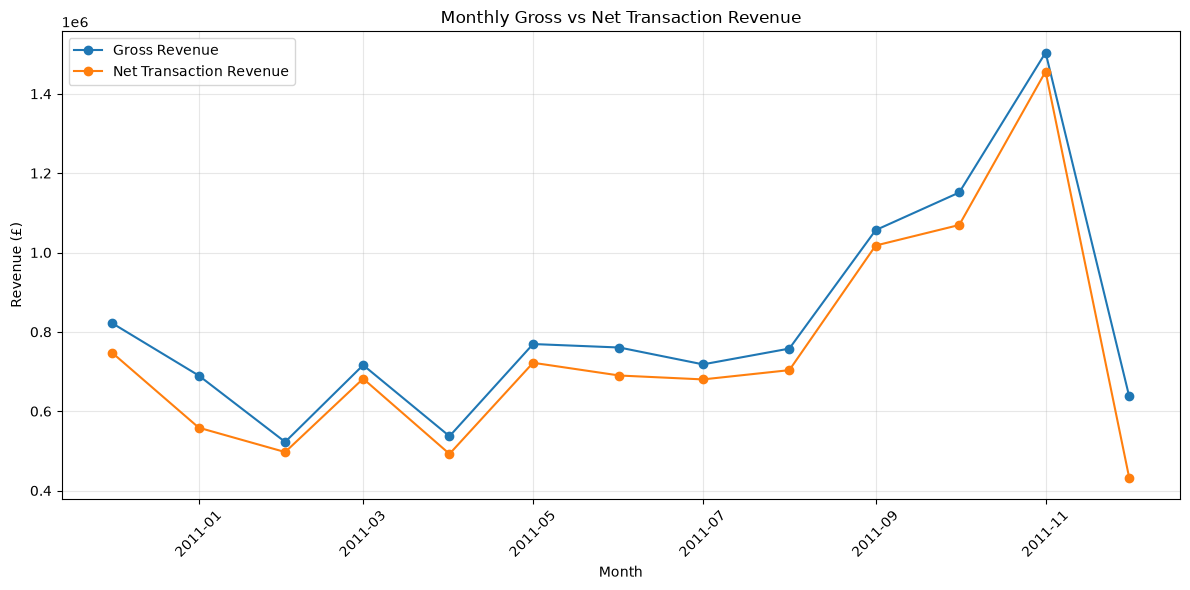

In [67]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_performance["Month"],
    monthly_performance["GrossRevenue"],
    marker="o",
    label="Gross Revenue"
)

plt.plot(
    monthly_performance["Month"],
    monthly_performance["NetTransactionRevenue"],
    marker="o",
    label="Net Transaction Revenue"
)

plt.title("Monthly Gross vs Net Transaction Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


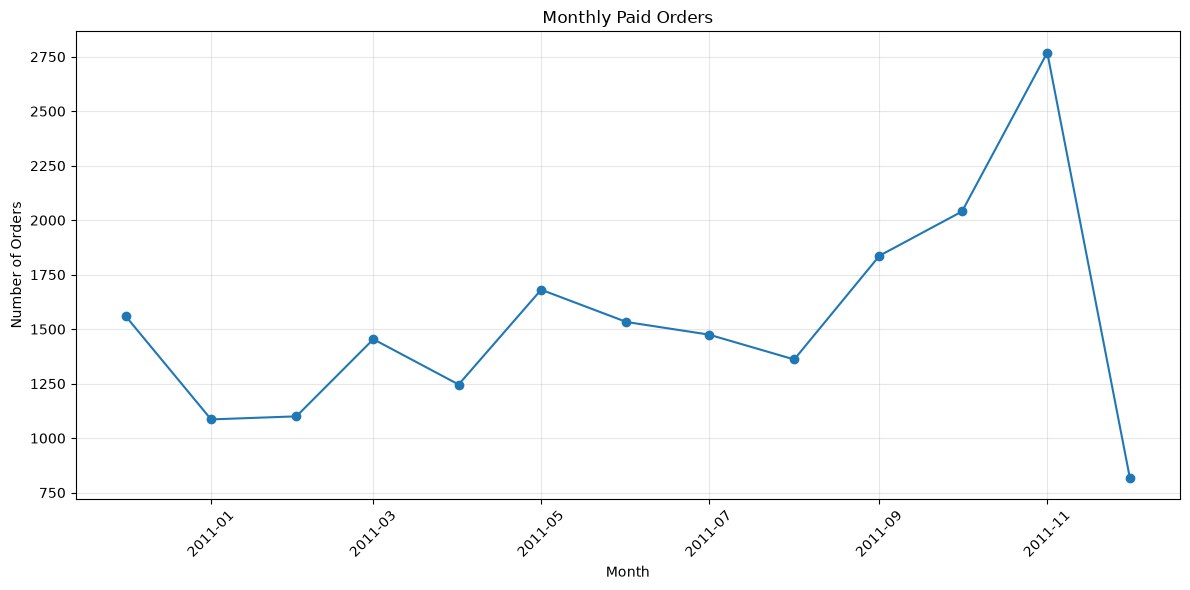

In [68]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_performance["Month"],
    monthly_performance["Orders"],
    marker="o"
)

plt.title("Monthly Paid Orders")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Finding 1 — Peak sales

November 2011 was the strongest complete month, with approximately £1.50M in gross revenue and 2,769 paid orders.

Finding 2 — Growth mechanism

Revenue accelerated substantially from September through November. The increase was accompanied by strong growth in order volume, while average order value remained relatively stable and even declined slightly, indicating that higher order volume was the primary driver.

Finding 3 — Cancellation variability

Cancellation value varied considerably across months. January 2011 recorded cancellation value equivalent to roughly 19% of gross revenue, compared with approximately 3.2% in November.

Note: December 2011 is a partial month containing transactions only through December 9 and is therefore excluded from full-month performance comparisons.

#### 4A.3 Revenue by Country

**Business question:** Which geographic markets contribute the most to gross sales revenue?


In [69]:
country_performance = (
    sales_df
    .groupby("Country", as_index=False)
    .agg(
        GrossRevenue=("Revenue", "sum"),
        Orders=("InvoiceNo", "nunique")
    )
    .sort_values("GrossRevenue", ascending=False)
)

In [70]:
country_performance["RevenueSharePct"] = (
    country_performance["GrossRevenue"]
    / country_performance["GrossRevenue"].sum()
    * 100
)

In [71]:
country_performance["AverageOrderValue"] = (
    country_performance["GrossRevenue"]
    / country_performance["Orders"]
)

In [72]:
country_performance[
    [
        "Country",
        "GrossRevenue",
        "Orders",
        "AverageOrderValue",
        "RevenueSharePct"
    ]
].head(10).round(2)

,Country,GrossRevenue,Orders,AverageOrderValue,RevenueSharePct
36,United Kingdom,9001744.09,18019,499.57,84.59
24,Netherlands,285446.34,94,3036.66,2.68
10,EIRE,283140.52,288,983.13,2.66
14,Germany,228678.40,457,500.39,2.15
13,France,209625.37,392,534.76,1.97
0,Australia,138453.81,57,2429.01,1.30
31,Spain,61558.56,90,683.98,0.58
33,Switzerland,57067.60,54,1056.81,0.54
3,Belgium,41196.34,98,420.37,0.39
32,Sweden,38367.83,36,1065.77,0.36


In [73]:
uk_performance = country_performance[
    country_performance["Country"] == "United Kingdom"
]

uk_performance

,Country,GrossRevenue,Orders,RevenueSharePct,AverageOrderValue
36,United Kingdom,9001744.094,18019,84.586078,499.569571


In [74]:
pd.Series({
    "Number of Countries": sales_df["Country"].nunique(),
    "UK Revenue Share (%)": uk_performance["RevenueSharePct"].iloc[0],
    "UK Gross Revenue": uk_performance["GrossRevenue"].iloc[0],
    "UK Orders": uk_performance["Orders"].iloc[0]
}).round(2)

Number of Countries          38.00
UK Revenue Share (%)         84.59
UK Gross Revenue        9001744.09
UK Orders                 18019.00
dtype: float64

In [75]:
top_non_uk = (
    country_performance[
        country_performance["Country"] != "United Kingdom"
    ]
    .head(10)
)

top_non_uk[
    ["Country", "GrossRevenue", "RevenueSharePct", "Orders"]
]

,Country,GrossRevenue,RevenueSharePct,Orders
24,Netherlands,285446.34,2.682234,94
10,EIRE,283140.52,2.660567,288
14,Germany,228678.40,2.148807,457
13,France,209625.37,1.969772,392
0,Australia,138453.81,1.301000,57
31,Spain,61558.56,0.578443,90
33,Switzerland,57067.60,0.536243,54
3,Belgium,41196.34,0.387107,98
32,Sweden,38367.83,0.360528,36
20,Japan,37416.37,0.351588,19


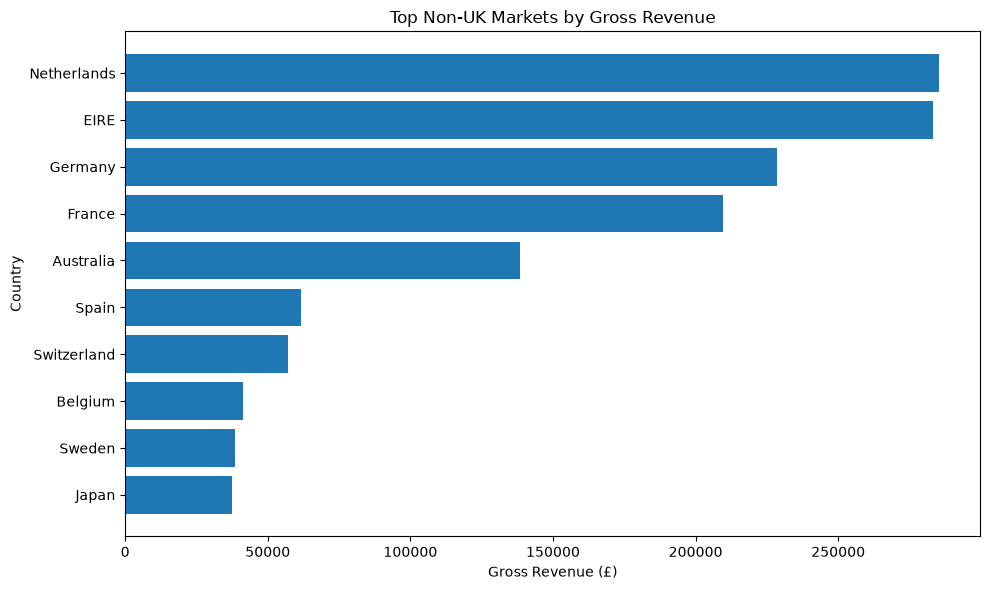

In [76]:
top_non_uk_plot = (
    country_performance[
        country_performance["Country"] != "United Kingdom"
    ]
    .head(10)
    .sort_values("GrossRevenue")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_non_uk_plot["Country"],
    top_non_uk_plot["GrossRevenue"]
)

plt.title("Top Non-UK Markets by Gross Revenue")
plt.xlabel("Gross Revenue (£)")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [77]:
country_performance[
    country_performance["Orders"] >= 20
].sort_values(
    "AverageOrderValue",
    ascending=False
)[
    [
        "Country",
        "Orders",
        "AverageOrderValue",
        "GrossRevenue"
    ]
].head(10).round(2)

,Country,Orders,AverageOrderValue,GrossRevenue
24,Netherlands,94,3036.66,285446.34
0,Australia,57,2429.01,138453.81
32,Sweden,36,1065.77,38367.83
33,Switzerland,54,1056.81,57067.60
25,Norway,36,1004.60,36165.44
10,EIRE,288,983.13,283140.52
6,Channel Islands,26,786.17,20440.54
31,Spain,90,683.98,61558.56
27,Portugal,58,580.74,33683.05
12,Finland,41,549.90,22546.08


Geographic Sales Performance: The United Kingdom dominates the business, accounting for 84.59% of gross revenue. Among international markets, purchasing patterns differ substantially. The Netherlands and Australia generate relatively high revenue despite modest order counts, with average order values of approximately £3,037 and £2,429 respectively, compared with about £500 in the UK. Germany and France, by contrast, generate revenue primarily through higher order volumes with average order values closer to the UK level. These differences suggest that international markets should be evaluated not only by total revenue but also by order size and purchasing behavior.

### 4B — Product Performance

**Business questions:**
- Which merchandise products generate the most revenue?
- Which products sell the most units?
- How do product rankings change after cancellations?


Gross product rankings can be distorted by large cancelled transactions, therefore product performance should also be evaluated after considering cancellations.

In [78]:
# These StockCodes were identified in the notebook outputs as charges,
# fees, or accounting/manual adjustments rather than merchandise products.
non_product_codes = [
    "DOT",        # DOTCOM POSTAGE
    "POST",       # POSTAGE
    "M",          # Manual
    "B",          # Adjust bad debt
    "AMAZONFEE"   # AMAZON FEE
]

sales_df[
    sales_df["StockCode"].isin(non_product_codes)
][["StockCode", "Description"]].drop_duplicates().sort_values("StockCode")


,StockCode,Description
15017,AMAZONFEE,AMAZON FEE
299982,B,Adjust bad debt
1814,DOT,DOTCOM POSTAGE
2239,M,Manual
45,POST,POSTAGE


#### Merchandise Product Dataset

Non-product charge/adjustment codes are excluded **only from product rankings**. They remain in the broader transaction dataset unless the business definition of total revenue is changed explicitly.


In [79]:
product_sales_df = sales_df[
    ~sales_df["StockCode"].isin(non_product_codes)
].copy()

In [80]:
product_sales_df["StockCode"].nunique()


3917

In [81]:
product_performance = (
    product_sales_df
    .groupby("StockCode", as_index=False)
    .agg(
        QuantitySold=("Quantity", "sum"),
        GrossRevenue=("Revenue", "sum"),
        Orders=("InvoiceNo", "nunique")
    )
)

In [82]:
product_names = (
    product_sales_df
    .groupby("StockCode")["Description"]
    .agg(
        lambda x: x.mode().iloc[0]
        if not x.mode().empty
        else x.iloc[0]
    )
    .reset_index()
)

product_performance = product_performance.merge(
    product_names,
    on="StockCode",
    how="left"
)

#### Top Merchandise Products by Gross Revenue

In [83]:
top_products_revenue = (
    product_performance
    .sort_values("GrossRevenue", ascending=False)
    .head(10)
)

top_products_revenue[
    ["StockCode", "Description", "GrossRevenue", "QuantitySold", "Orders"]
].round(2)


,StockCode,Description,GrossRevenue,QuantitySold,Orders
1235,22423,REGENCY CAKESTAND 3 TIER,174156.54,13851,1988
2390,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
3539,85123A,WHITE HANGING HEART T-LIGHT HOLDER,104462.75,37641,2198
2468,47566,PARTY BUNTING,99445.23,18283,1685
3528,85099B,JUMBO BAG RED RETROSPOT,94159.81,48371,2089
1945,23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247
1867,23084,RABBIT NIGHT LIGHT,66870.03,30739,994
931,22086,PAPER CHAIN KIT 50'S CHRISTMAS,64875.59,19329,1160
2666,84879,ASSORTED COLOUR BIRD ORNAMENT,58927.62,36362,1455
2532,79321,CHILLI LIGHTS,54096.36,10302,661


#### Top Merchandise Products by Quantity

In [84]:
top_products_quantity = (
    product_performance
    .sort_values("QuantitySold", ascending=False)
    .head(10)
)

top_products_quantity[
    ["StockCode", "Description", "QuantitySold", "GrossRevenue", "Orders"]
].round(2)

,StockCode,Description,QuantitySold,GrossRevenue,Orders
2390,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1
1945,23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,81700.92,247
1034,22197,POPCORN HOLDER,56898,51334.47,1392
2562,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951,13814.01,535
3528,85099B,JUMBO BAG RED RETROSPOT,48371,94159.81,2089
3539,85123A,WHITE HANGING HEART T-LIGHT HOLDER,37641,104462.75,2198
364,21212,PACK OF 72 RETROSPOT CAKE CASES,36396,21246.45,1320
2666,84879,ASSORTED COLOUR BIRD ORNAMENT,36362,58927.62,1455
1867,23084,RABBIT NIGHT LIGHT,30739,66870.03,994
1299,22492,MINI PAINT SET VINTAGE,26633,16937.82,380


#### Cancellation Treatment

Cancelled transactions should not simply be deleted from the product story. Gross product performance shows recorded positive sales, while **net product performance** subtracts recorded cancellation value to estimate realized product contribution.


#### Product Analysis Views

1. **Gross Product Performance** — Which merchandise products generated the highest recorded positive sales?
2. **Net Product Performance** — Which merchandise products contributed the most after recorded cancellations?


In [85]:
product_performance["RevenuePerOrder"] = (
    product_performance["GrossRevenue"]
    / product_performance["Orders"]
)

In [86]:
product_performance.sort_values(
    "RevenuePerOrder",
    ascending=False
).head(10)

,StockCode,QuantitySold,GrossRevenue,Orders,Description,RevenuePerOrder
2390,23843,80995,168469.60,1,"PAPER CRAFT , LITTLE BIRDIE",168469.600000
3066,47556B,2600,6045.00,2,TEA TIME TEA TOWELS,3022.500000
1101,22275,69,527.85,1,WEEKEND BAG VINTAGE ROSE PAISLEY,527.850000
1627,22833,76,2603.53,5,HALL CABINET WITH 3 DRAWERS,520.706000
1624,22830,131,2610.29,6,UTILTY CABINET WITH HOOKS,435.048333
805,21897,405,1268.19,3,POTTING SHED CANDLE CITRONELLA,422.730000
1945,23166,78033,81700.92,247,MEDIUM CERAMIC TOP STORAGE JAR,330.772955
719,21769,11,607.65,2,VINTAGE POST OFFICE CABINET,303.825000
1622,22828,10,1530.00,7,REGENCY MIRROR WITH SHUTTERS,218.571429
1455,22655,60,8125.00,38,VINTAGE RED KITCHEN CABINET,213.815789


In [87]:
product_cancellations = (
    cancellations_df[
        ~cancellations_df["StockCode"].isin(non_product_codes)
    ]
    .groupby("StockCode", as_index=False)
    .agg(
        CancellationValue=("Revenue", lambda x: -x.sum())
    )
)


In [88]:
product_net = product_performance.merge(
    product_cancellations,
    on="StockCode",
    how="left"
)

In [89]:
product_net["CancellationValue"] = (
    product_net["CancellationValue"]
    .fillna(0)
)

In [90]:
product_net["NetRevenue"] = (
    product_net["GrossRevenue"]
    - product_net["CancellationValue"]
)

#### Top Merchandise Products by Net Revenue

In [91]:
product_net.sort_values(
    "NetRevenue",
    ascending=False
).head(10)

,StockCode,QuantitySold,GrossRevenue,Orders,Description,RevenuePerOrder,CancellationValue,NetRevenue
1235,22423,13851,174156.54,1988,REGENCY CAKESTAND 3 TIER,87.603893,9697.05,164459.49
2468,47566,18283,99445.23,1685,PARTY BUNTING,59.017941,1201.35,98243.88
3539,85123A,37641,104462.75,2198,WHITE HANGING HEART T-LIGHT HOLDER,47.526274,6624.30,97838.45
3528,85099B,48371,94159.81,2089,JUMBO BAG RED RETROSPOT,45.074107,1984.02,92175.79
1867,23084,30739,66870.03,994,RABBIT NIGHT LIGHT,67.273672,208.40,66661.63
931,22086,19329,64875.59,1160,PAPER CHAIN KIT 50'S CHRISTMAS,55.927233,1160.35,63715.24
2666,84879,36362,58927.62,1455,ASSORTED COLOUR BIRD ORNAMENT,40.500082,135.20,58792.42
2532,79321,10302,54096.36,661,CHILLI LIGHTS,81.840182,349.70,53746.66
1309,22502,1937,51408.77,463,PICNIC BASKET WICKER SMALL,111.034060,385.25,51023.52
1034,22197,56898,51334.47,1392,POPCORN HOLDER,36.878211,366.55,50967.92


In [92]:
top10_share = (
    product_net
    .sort_values("NetRevenue", ascending=False)
    .head(10)["NetRevenue"]
    .sum()
    /
    product_net["NetRevenue"].sum()
    * 100
)

top10_share

np.float64(8.164868501916585)

### 4C — Customer Analytics

**Business questions:**
- Who are the highest-value identified customers?
- How much net revenue comes from repeat customers?
- Is customer revenue concentrated among a relatively small group?

In [93]:
customer_summary = (
    customer_df
    .groupby("CustomerID")
    .agg(
        Orders=("InvoiceNo", "nunique"),
        GrossRevenue=("Revenue", "sum"),
        TotalQuantity=("Quantity", "sum"),
        FirstPurchase=("InvoiceDate", "min"),
        LastPurchase=("InvoiceDate", "max")
    )
    .reset_index()
)


In [94]:
customer_summary["GrossAOV"] = (
    customer_summary["GrossRevenue"]
    / customer_summary["Orders"]
)


In [95]:
customer_summary["ObservedActiveSpanDays"] = (
    customer_summary["LastPurchase"]
    - customer_summary["FirstPurchase"]
).dt.days


In [96]:
customer_summary.head()

,CustomerID,Orders,GrossRevenue,TotalQuantity,FirstPurchase,LastPurchase,GrossAOV,ObservedActiveSpanDays
0,12346,1,77183.60,74215,2011-01-18 10:01:00,2011-01-18 10:01:00,77183.600000,0
1,12347,7,4310.00,2458,2010-12-07 14:57:00,2011-12-07 15:52:00,615.714286,365
2,12348,4,1797.24,2341,2010-12-16 19:09:00,2011-09-25 13:13:00,449.310000,282
3,12349,1,1757.55,631,2011-11-21 09:51:00,2011-11-21 09:51:00,1757.550000,0
4,12350,1,334.40,197,2011-02-02 16:01:00,2011-02-02 16:01:00,334.400000,0


In [97]:
customer_cancellations = (
    cancellations_df[
        cancellations_df["CustomerID"].notna()
    ]
    .groupby("CustomerID", as_index=False)
    .agg(
        CancellationValue=("Revenue", lambda x: -x.sum())
    )
)

customer_summary = customer_summary.merge(
    customer_cancellations,
    on="CustomerID",
    how="left"
)

customer_summary["CancellationValue"] = (
    customer_summary["CancellationValue"].fillna(0)
)

customer_summary["NetRevenue"] = (
    customer_summary["GrossRevenue"]
    - customer_summary["CancellationValue"]
)

customer_summary["CustomerType"] = np.where(
    customer_summary["Orders"] > 1,
    "Repeat",
    "One-time"
)


In [98]:
top_customers_net = (
    customer_summary
    .sort_values(
        "NetRevenue",
        ascending=False
    )
    .head(10)
)

top_customers_net[
    [
        "CustomerID",
        "Orders",
        "GrossRevenue",
        "CancellationValue",
        "NetRevenue",
        "GrossAOV"
    ]
].round(2)

,CustomerID,Orders,GrossRevenue,CancellationValue,NetRevenue,GrossAOV
1689,14646,73,280206.02,717.00,279489.02,3838.44
4201,18102,60,259657.30,3218.81,256438.49,4327.62
3728,17450,46,194390.79,7068.62,187322.17,4225.89
1879,14911,201,143711.17,11252.44,132458.73,714.98
55,12415,21,124914.53,1189.08,123725.45,5948.31
1333,14156,55,117210.08,3995.49,113214.59,2131.09
3771,17511,31,91062.38,2937.00,88125.38,2937.50
3176,16684,28,66653.56,761.48,65892.08,2380.48
996,13694,50,65039.62,2349.08,62690.54,1300.79
2176,15311,91,60632.75,1348.56,59284.19,666.29


In [99]:
customer_summary[
    customer_summary["CustomerID"] == 16446
][
    [
        "CustomerID",
        "Orders",
        "GrossRevenue",
        "CancellationValue",
        "NetRevenue"
    ]
]

,CustomerID,Orders,GrossRevenue,CancellationValue,NetRevenue
3008,16446,2,168472.5,168469.6,2.9


In [100]:
customer_summary[
    customer_summary["CustomerID"] == 12346
][
    [
        "CustomerID",
        "Orders",
        "GrossRevenue",
        "CancellationValue",
        "NetRevenue"
    ]
]

,CustomerID,Orders,GrossRevenue,CancellationValue,NetRevenue
0,12346,1,77183.6,77183.6,0.0


Customer value rankings based only on gross sales can be materially distorted by fully cancelled high-value transactions. Net transaction revenue therefore provides a more reliable measure of realized customer contribution.


In [101]:
repeat_analysis_net = (
    customer_summary
    .groupby("CustomerType")
    .agg(
        Customers=("CustomerID", "count"),
        NetRevenue=("NetRevenue", "sum")
    )
    .reset_index()
)

repeat_analysis_net

,CustomerType,Customers,NetRevenue
0,One-time,1493,518843.641
1,Repeat,2845,7770087.023


In [102]:
repeat_net_revenue_share = (
    repeat_analysis_net.loc[
        repeat_analysis_net["CustomerType"] == "Repeat",
        "NetRevenue"
    ].iloc[0]
    /
    customer_summary["NetRevenue"].sum()
    * 100
)

repeat_net_revenue_share

np.float64(93.74052381384476)

**Repeat-customer finding:** Repeat customers represent 65.58% of identified customers but contribute 93.74% of identified net customer revenue, indicating that repeat purchasing is strongly associated with revenue generation.


The customer analysis uses **net revenue** for value rankings and concentration metrics so that large cancelled transactions do not inflate customer value.


#### Revenue Concentration / Pareto Analysis

**Business question:** Is net customer revenue concentrated among a relatively small group of revenue-generating customers?


In [103]:
pd.Series({
    "Positive Net Revenue": (customer_summary["NetRevenue"] > 0).sum(),
    "Zero Net Revenue": (customer_summary["NetRevenue"] == 0).sum(),
    "Negative Net Revenue": (customer_summary["NetRevenue"] < 0).sum()
})


Positive Net Revenue    4319
Zero Net Revenue           6
Negative Net Revenue      13
dtype: int64

In [104]:
customer_summary[
    customer_summary["NetRevenue"] < 0
][
    [
        "CustomerID",
        "GrossRevenue",
        "CancellationValue",
        "NetRevenue"
    ]
].sort_values("NetRevenue").head(10)

,CustomerID,GrossRevenue,CancellationValue,NetRevenue
3839,17603,394.72,1560.02,-1.165300e+03
2558,15823,15.00,855.76,-8.407600e+02
2540,15802,451.42,902.84,-4.514200e+02
3798,17548,103.30,244.78,-1.414800e+02
3078,16546,787.15,883.08,-9.593000e+01
983,13672,186.39,257.85,-7.146000e+01
1531,14437,63.00,106.40,-4.340000e+01
3014,16454,6.90,15.05,-8.150000e+00
210,12607,1579.51,1579.51,-2.273737e-13
1629,14557,788.38,788.38,-1.136868e-13


In [105]:
# Pareto analysis focuses on customers who generated positive net revenue.
# Zero/negative-net customers remain in overall revenue calculations.
pareto_customers = (
    customer_summary[
        customer_summary["NetRevenue"] > 0
    ]
    .sort_values("NetRevenue", ascending=False)
    .reset_index(drop=True)
    .copy()
)


In [106]:
pareto_customers["CustomerRank"] = (
    np.arange(1, len(pareto_customers) + 1)
)

pareto_customers["CumulativeCustomerShare"] = (
    pareto_customers["CustomerRank"]
    / len(pareto_customers)
)

pareto_customers["CumulativeNetRevenue"] = (
    pareto_customers["NetRevenue"].cumsum()
)

positive_net_revenue = (
    pareto_customers["NetRevenue"].sum()
)

pareto_customers["CumulativeRevenueShare"] = (
    pareto_customers["CumulativeNetRevenue"]
    / positive_net_revenue
)

In [107]:
threshold_80 = pareto_customers[
    pareto_customers["CumulativeRevenueShare"] >= 0.80
].iloc[0]

customers_for_80_pct = int(
    threshold_80["CustomerRank"]
)

customer_pct_for_80_revenue = (
    threshold_80["CumulativeCustomerShare"] * 100
)

print(
    f"{customers_for_80_pct:,} customers "
    f"({customer_pct_for_80_revenue:.2f}%) "
    f"generate approximately 80% of positive net customer revenue."
)

1,175 customers (27.21%) generate approximately 80% of positive net customer revenue.


In [108]:
top_20_count = int(
    np.ceil(len(pareto_customers) * 0.20)
)

top_20_revenue_share = (
    pareto_customers
    .head(top_20_count)["NetRevenue"]
    .sum()
    / positive_net_revenue
    * 100
)

print(
    f"Top 20% of revenue-generating customers account for "
    f"{top_20_revenue_share:.2f}% of positive net customer revenue."
)

Top 20% of revenue-generating customers account for 73.54% of positive net customer revenue.


In [109]:
top_10_customer_share = (
    pareto_customers
    .head(10)["NetRevenue"]
    .sum()
    / positive_net_revenue
    * 100
)

print(
    f"Top 10 customers account for "
    f"{top_10_customer_share:.2f}% of positive net customer revenue."
)

Top 10 customers account for 16.51% of positive net customer revenue.


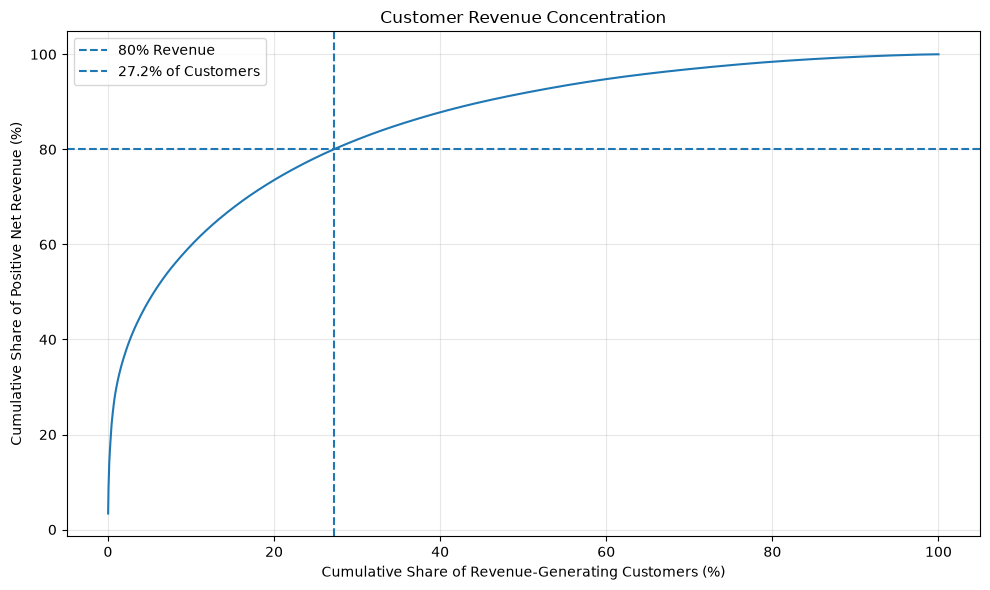

In [110]:
plt.figure(figsize=(10, 6))

plt.plot(
    pareto_customers["CumulativeCustomerShare"] * 100,
    pareto_customers["CumulativeRevenueShare"] * 100
)

plt.axhline(
    y=80,
    linestyle="--",
    label="80% Revenue"
)

plt.axvline(
    x=customer_pct_for_80_revenue,
    linestyle="--",
    label=f"{customer_pct_for_80_revenue:.1f}% of Customers"
)

plt.title("Customer Revenue Concentration")
plt.xlabel("Cumulative Share of Revenue-Generating Customers (%)")
plt.ylabel("Cumulative Share of Positive Net Revenue (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Customer Analytics Findings

- Repeat customers account for **65.58%** of identified customers and **93.74%** of identified net customer revenue.
- After excluding zero/negative-net customers from the Pareto denominator, approximately **27.21%** of revenue-generating customers account for 80% of positive net customer revenue.
- The top **20%** of revenue-generating customers account for approximately **73.54%** of positive net customer revenue.
- The top **10 customers** account for approximately **16.51%** of positive net customer revenue.

These results indicate meaningful customer-level revenue concentration, while also showing that the classic 80/20 rule does not hold exactly for this dataset.

## Final Business Insights & Recommendations

### 1. Repeat customers are the main revenue driver

**Finding:** Repeat customers represent **65.58%** of identified customers but generate approximately **93.74% of identified net customer revenue**.

**Interpretation:** Revenue generation is strongly associated with customers who purchase more than once.

**Business implication:** Losing valuable repeat customers could have a disproportionate impact on revenue.

**Recommendation:** Prioritize retention initiatives for repeat and high-value customers, such as targeted offers, loyalty programs, and customer-level monitoring.

---

### 2. Revenue is highly concentrated in the UK market

**Finding:** The United Kingdom accounts for approximately **84.59% of gross revenue**. However, some international markets show substantially higher average order values, including the **Netherlands (£3,036.66)** and **Australia (£2,429.01)** compared with approximately **£499.57 in the UK**.

**Interpretation:** The business is heavily dependent on its domestic UK market, while some smaller international markets exhibit different purchasing patterns and significantly larger order sizes.

**Business implication:** High-AOV international markets may represent valuable customer segments, although revenue alone is not sufficient to justify expansion.

**Recommendation:** Further investigate product mix, customer behavior, logistics costs, and profitability in high-AOV international markets such as the Netherlands and Australia before making expansion decisions.

---

### 3. Late-2011 revenue growth was primarily driven by higher order volume

**Finding:** November 2011 was the strongest complete month in the dataset, generating approximately **£1.50M in gross revenue from 2,769 paid orders**, with month-over-month gross revenue growth of approximately **30.63%**. From September through November, revenue and order volume increased substantially while average order value remained relatively stable and slightly declined.

**Interpretation:** The revenue increase during this period was primarily associated with higher order volume rather than customers spending more per order.

**Business implication:** Peak-period performance appears to be volume-driven, which may create additional inventory, fulfillment, and operational capacity requirements.

**Recommendation:** Investigate the seasonal and operational factors behind the September-November increase to support inventory and capacity planning during future peak periods.

> **Note:** December 2011 contains transactions only through December 9 and is therefore excluded from full-month performance comparisons.

---

### 4. Gross sales rankings can overstate actual customer and product performance

**Finding:** Several apparently high-value customers and products were driven by large transactions that were subsequently cancelled. For example, Customer **16446** recorded **£168,472.50** in gross revenue but **£168,469.60** in cancellation value, resulting in only **£2.90 of net revenue**. Customer **12346** recorded **£77,183.60** in gross revenue that was fully cancelled.

**Interpretation:** Rankings based solely on gross sales can materially overstate the realized contribution of customers and products.

**Business implication:** Decisions based only on gross transaction values may incorrectly prioritize cancelled or reversed transactions.

**Recommendation:** Use both gross and cancellation-adjusted net metrics when evaluating customer and product performance.

---

### 5. Customer revenue is meaningfully concentrated, but the classic 80/20 rule does not hold exactly

**Finding:** Approximately **27.21% of revenue-generating customers account for 80% of positive net customer revenue**. The top **20% of customers generate 73.54%**, while the top **10 customers generate 16.51%**.

**Interpretation:** Revenue is concentrated among higher-value customer segments, although the concentration is less extreme than the traditional 80/20 Pareto pattern.

**Business implication:** High-value customers are commercially important, but revenue is not dependent on only a handful of individual accounts.

**Recommendation:** Prioritize high-value customer segments for retention and account-level monitoring while maintaining a broader customer strategy to avoid excessive dependence on a small number of customers.

In [111]:
transactions_sql = df_clean.copy()

transactions_sql["Revenue"] = (
    transactions_sql["Quantity"]
    * transactions_sql["UnitPrice"]
)

transactions_sql["TransactionType"] = np.select(
    [
        transactions_sql["IsCancellation"],
        transactions_sql["IsOperationalAdjustment"],
        transactions_sql["IsNegativePrice"],
        transactions_sql["IsZeroPrice"]
    ],
    [
        "Cancellation",
        "Operational Adjustment",
        "Accounting Adjustment",
        "Zero Price"
    ],
    default="Paid Sale"
)

In [112]:
transactions_sql = transactions_sql[
    [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "UnitPrice",
        "CustomerID",
        "Country",
        "Revenue",
        "TransactionType"
    ]
].copy()

In [113]:
transactions_sql.to_csv(
    "../data/online_retail_clean.csv",
    index=False
)